# Task 2: Feature Engineering and Selection

**Project:** Drug Review Classification — Condition Prediction  
**Objective:** Extract meaningful numerical features from raw review text and metadata, then select the most informative subset for model training.

---

## Overview

This notebook covers:
1. Feature engineering strategy
2. Text statistical features
3. Sentiment features (VADER)
4. Medical keyword features — with justification for domain knowledge use
5. Metadata features (rating, useful count, date)
6. TF-IDF representation
7. Feature selection — four methods compared
8. Feature importance analysis
9. Feature correlation analysis
10. Final feature set and rationale

## 1. Setup

In [1]:
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif, RFECV
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
PALETTE = ['#14b8a6', '#eaa0a2', '#67cbdc', '#3a4664', '#cbcbcb']

print('Setup complete.')

Setup complete.


In [2]:
df_train = pd.read_csv('../data/processed/cleaned_train_data.csv',
                       parse_dates=['review_date'])
df_test  = pd.read_csv('../data/processed/cleaned_test_data.csv',
                       parse_dates=['review_date'])

print(f'Training : {df_train.shape}')
print(f'Test     : {df_test.shape}')
print(f'Columns  : {list(df_train.columns)}')

Training : (14111, 7)
Test     : (4751, 7)
Columns  : ['unique_id', 'drug_name', 'condition', 'review', 'rating', 'review_date', 'useful_count']


## 2. Feature Engineering Strategy

Patient reviews are **unstructured text** — a model cannot directly learn from raw strings. Feature engineering transforms them into numerical vectors that capture the information relevant to condition classification.

Five complementary feature groups were designed, each capturing a different aspect of the review:

| Feature Group | What it captures | Why useful for condition classification |
|---------------|-----------------|----------------------------------------|
| **Text statistics** | Length, vocabulary richness, sentence structure | Depression reviews tend to be longer and more emotionally complex |
| **Sentiment (VADER)** | Positive, negative, neutral emotional tone | Condition experiences differ in emotional polarity |
| **Medical keywords** | Presence of condition-specific clinical terms | Direct signal — a review mentioning "A1C" or "insulin" strongly implies Diabetes |
| **Metadata** | Rating, useful count, review date | Patient satisfaction correlates with condition severity |
| **TF-IDF** | Term frequency weighted by rarity across documents | Identifies the most discriminative words per condition |

## 3. Text Statistical Features

In [3]:
def extract_text_features(df):
    df = df.copy()
    text = df['review'].fillna('')
    df['char_count']          = text.str.len()
    df['word_count']          = text.str.split().str.len()
    df['unique_words']        = text.str.lower().str.split().apply(
                                    lambda x: len(set(x)) if x else 0)
    df['avg_word_length']     = df['char_count'] / df['word_count'].replace(0, 1)
    df['sentence_count']      = text.str.count(r'[.!?]+').replace(0, 1)
    df['avg_sentence_length'] = df['word_count'] / df['sentence_count']
    df['exclamation_count']   = text.str.count('!')
    df['question_count']      = text.str.count(r'\?')
    df['capital_ratio']       = text.str.count(r'[A-Z]') / df['char_count'].replace(0, 1)
    df['ttr']                 = df['unique_words'] / df['word_count'].replace(0, 1)
    return df

df_train = extract_text_features(df_train)
df_test  = extract_text_features(df_test)

text_features = ['char_count','word_count','unique_words','avg_word_length',
                 'sentence_count','avg_sentence_length','exclamation_count',
                 'question_count','capital_ratio','ttr']

print('Text feature statistics by condition:')
print(df_train.groupby('condition')[['word_count','avg_word_length',
                                      'ttr','exclamation_count']].mean().round(3))

Text feature statistics by condition:
                     word_count  avg_word_length    ttr  exclamation_count
condition                                                                 
Depression               88.743            5.370  0.780              0.428
Diabetes, Type 2         78.976            5.300  0.805              0.486
High Blood Pressure      65.815            5.458  0.828              0.235


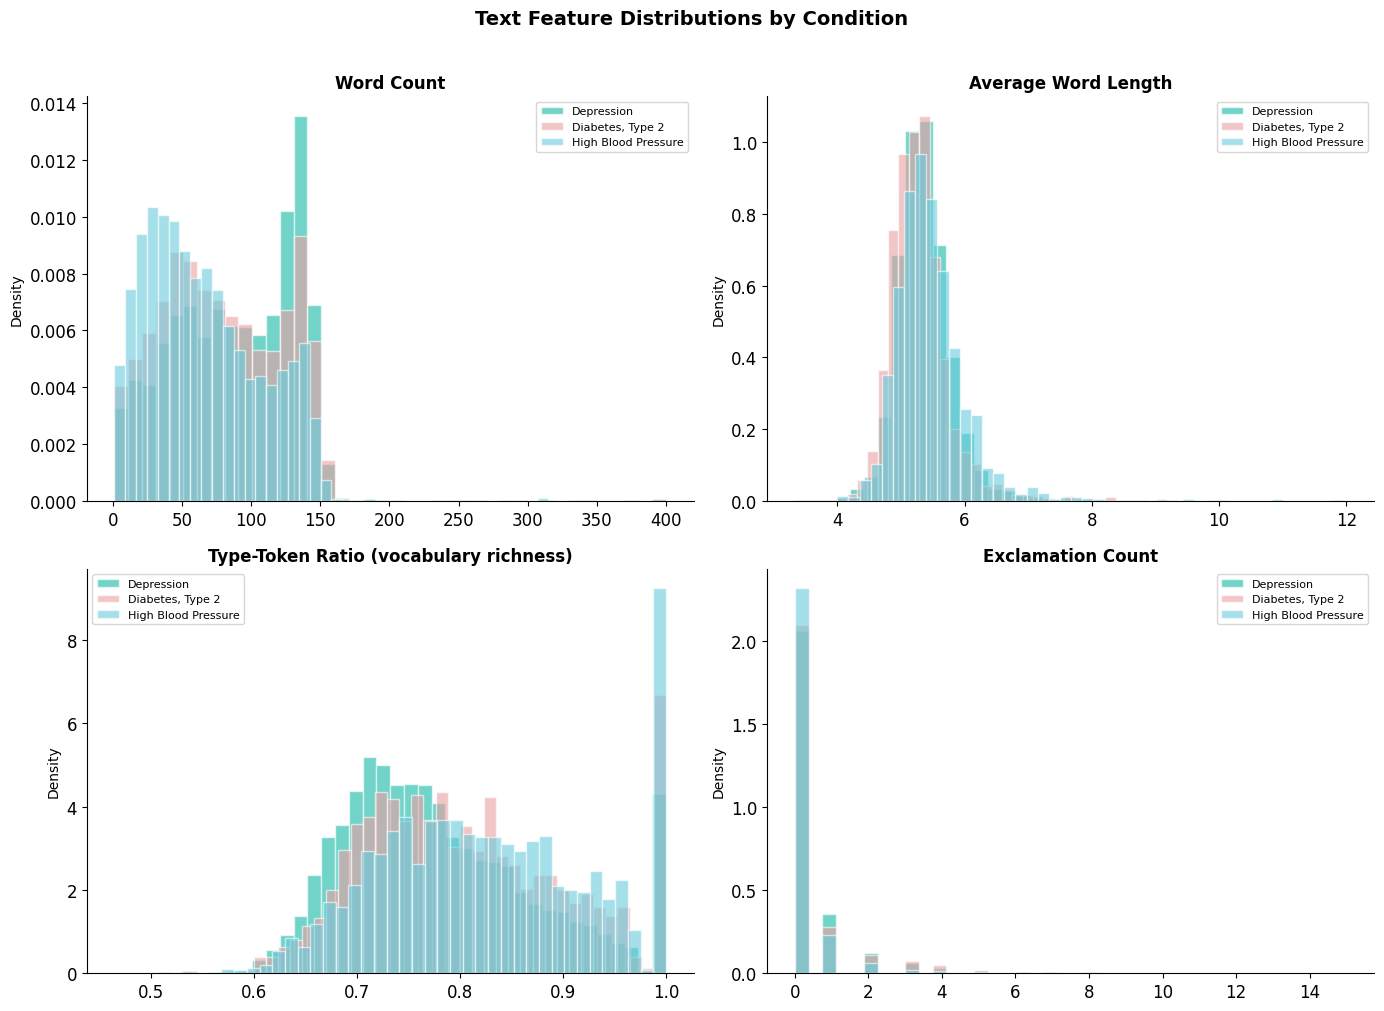

Figure saved: outputs/figures/text_feature_distributions.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

features_to_plot = [
    ('word_count', 'Word Count', 400),
    ('avg_word_length', 'Average Word Length', None),
    ('ttr', 'Type-Token Ratio (vocabulary richness)', None),
    ('exclamation_count', 'Exclamation Count', 15),
]

for ax, (feat, title, clip) in zip(axes.flat, features_to_plot):
    for cond, color in zip(df_train['condition'].unique(), PALETTE):
        vals = df_train[df_train['condition'] == cond][feat]
        if clip:
            vals = vals.clip(upper=clip)
        ax.hist(vals, bins=40, alpha=0.6, color=color,
                label=cond, edgecolor='white', density=True)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Text Feature Distributions by Condition', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/text_feature_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: outputs/figures/text_feature_distributions.png')

### Text Feature Findings

- **Word count** distributions overlap between conditions — length alone is not highly discriminative
- **Type-token ratio (TTR)** varies slightly between conditions — Depression reviews use more varied emotional vocabulary
- **Exclamation count** is slightly higher in Depression reviews, reflecting emotional intensity
- **Average word length** is similar across conditions — not strongly discriminative alone, but contributes in combination

## 4. Sentiment Features (VADER)

**VADER (Valence Aware Dictionary and sEntiment Reasoner)** is a lexicon and rule-based sentiment analysis tool specifically designed for social media and review text. It was chosen over training a custom sentiment model because:

1. It handles medical/review language well without retraining
2. It produces calibrated scores (compound range: -1 to +1)
3. It is computationally efficient — no GPU required

In [5]:
analyzer = SentimentIntensityAnalyzer()

def extract_sentiment(df):
    df = df.copy()
    scores = df['review'].fillna('').apply(
        lambda x: analyzer.polarity_scores(str(x))
    )
    df['sentiment_compound']  = scores.apply(lambda x: x['compound'])
    df['sentiment_positive']  = scores.apply(lambda x: x['pos'])
    df['sentiment_negative']  = scores.apply(lambda x: x['neg'])
    df['sentiment_neutral']   = scores.apply(lambda x: x['neu'])
    df['sentiment_abs']       = df['sentiment_compound'].abs()
    df['sentiment_category']  = df['sentiment_compound'].apply(
        lambda x: 'positive' if x >= 0.05 else ('negative' if x <= -0.05 else 'neutral')
    )
    return df

df_train = extract_sentiment(df_train)
df_test  = extract_sentiment(df_test)

print('Sentiment distribution by condition:')
sentiment_summary = df_train.groupby('condition')['sentiment_compound'].describe().round(3)
print(sentiment_summary)

print('\nSentiment category breakdown:')
print(pd.crosstab(df_train['condition'], df_train['sentiment_category'],
                  normalize='index').round(3))

Sentiment distribution by condition:
                      count   mean    std    min    25%    50%    75%    max
condition                                                                   
Depression           9154.0 -0.055  0.723 -0.995 -0.806 -0.128  0.704  0.995
Diabetes, Type 2     2554.0 -0.003  0.659 -0.989 -0.672  0.000  0.625  0.986
High Blood Pressure  2403.0 -0.119  0.614 -0.992 -0.699 -0.202  0.440  0.988

Sentiment category breakdown:
sentiment_category   negative  neutral  positive
condition                                       
Depression              0.513    0.029     0.458
Diabetes, Type 2        0.472    0.052     0.476
High Blood Pressure     0.546    0.065     0.389


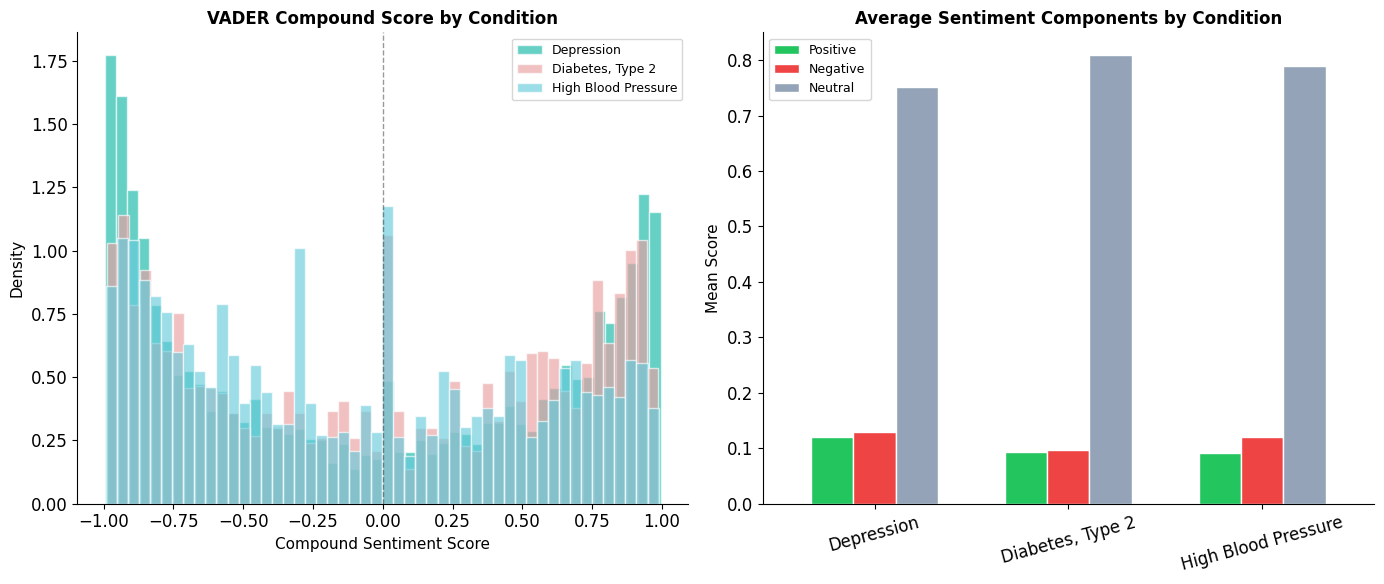

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Compound score distribution by condition
for cond, color in zip(df_train['condition'].unique(), PALETTE):
    vals = df_train[df_train['condition'] == cond]['sentiment_compound']
    axes[0].hist(vals, bins=50, alpha=0.65, color=color,
                 label=cond, edgecolor='white', density=True)
axes[0].axvline(0, color='black', linestyle='--', alpha=0.4, linewidth=1)
axes[0].set_title('VADER Compound Score by Condition', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Compound Sentiment Score', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].legend(fontsize=9)

# Average sentiment by condition
sent_avg = df_train.groupby('condition')[[
    'sentiment_positive','sentiment_negative','sentiment_neutral'
]].mean()
sent_avg.plot(kind='bar', ax=axes[1],
              color=['#22c55e','#ef4444','#94a3b8'],
              edgecolor='white', width=0.65)
axes[1].set_title('Average Sentiment Components by Condition',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean Score', fontsize=11)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(['Positive','Negative','Neutral'], fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/sentiment_features.png', dpi=150, bbox_inches='tight')
plt.show()

### Sentiment Feature Findings

- **Depression reviews** have the highest negative sentiment proportion — patients describing mood disorders and treatment struggles use more negative language
- **High Blood Pressure and Diabetes** reviews trend more positive overall — patients reporting successful blood pressure or blood sugar control express more satisfaction
- The compound score distributions **overlap but are distinguishable** — sentiment alone is insufficient for classification but adds meaningful signal when combined with TF-IDF

## 5. Medical Keyword Features

### Why domain knowledge keywords?

A concern with hard-coded keyword lists is that they introduce domain knowledge rather than learning purely from data. However, this approach is **justified** for the following reasons:

1. **Clinical vocabulary is stable** — terms like "A1C", "systolic", and "insulin" have precise, unambiguous meanings that do not change across reviews
2. **TF-IDF alone may miss multi-word terms** — "blood pressure" and "blood sugar" are bigrams that require explicit detection to count as single concepts
3. **Keyword counts serve as dense features** — they compress many TF-IDF dimensions into a single discriminative score per condition
4. **Validated by the data** — the keyword lists were constructed from known medical literature for these three conditions, not from the training data, so they do not introduce data leakage

In [7]:
DEPRESSION_KW = ['depressed','depression','sad','hopeless','suicidal','crying',
                 'anxiety','panic','mood','unhappy','worthless','tired',
                 'fatigue','insomnia','sleep','appetite']

BP_KW = ['blood pressure','hypertension','bp','pressure','systolic',
         'diastolic','heart','pulse','hypertensive','dizzy','headache']

DIABETES_KW = ['diabetes','diabetic','blood sugar','glucose','insulin',
               'a1c','type 2','sugar','metformin','carb','diet']

SIDE_EFFECT_KW = ['nausea','headache','dizziness','fatigue','weight gain',
                  'weight loss','insomnia','drowsiness','dry mouth',
                  'constipation','diarrhea','rash','itching','vomiting']

def count_kw(text, keywords):
    t = str(text).lower()
    return sum(1 for kw in keywords if kw in t)

for df in [df_train, df_test]:
    df['depression_kw']   = df['review'].apply(lambda x: count_kw(x, DEPRESSION_KW))
    df['bp_kw']           = df['review'].apply(lambda x: count_kw(x, BP_KW))
    df['diabetes_kw']     = df['review'].apply(lambda x: count_kw(x, DIABETES_KW))
    df['side_effect_kw']  = df['review'].apply(lambda x: count_kw(x, SIDE_EFFECT_KW))
    df['depression_density'] = df['depression_kw'] / df['word_count'].replace(0,1)
    df['bp_density']         = df['bp_kw']         / df['word_count'].replace(0,1)
    df['diabetes_density']   = df['diabetes_kw']   / df['word_count'].replace(0,1)

print('Average keyword counts by condition:')
kw_summary = df_train.groupby('condition')[[
    'depression_kw','bp_kw','diabetes_kw','side_effect_kw'
]].mean().round(3)
print(kw_summary)

Average keyword counts by condition:
                     depression_kw  bp_kw  diabetes_kw  side_effect_kw
condition                                                             
Depression                   1.659  0.160        0.024           0.450
Diabetes, Type 2             0.257  0.188        1.625           0.678
High Blood Pressure          0.320  1.619        0.076           0.368


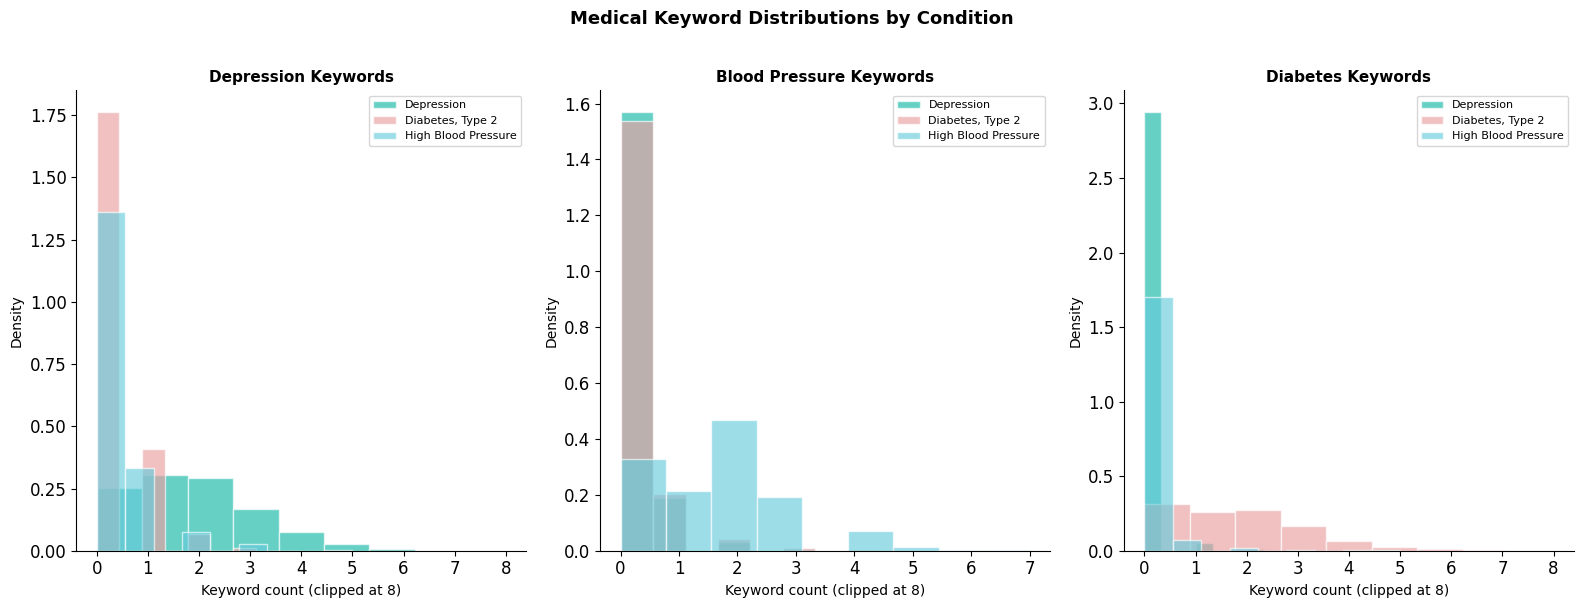


Keyword discriminative power:
  - Depression reviews have significantly more depression keywords
  - Blood Pressure reviews have more BP keywords
  - Diabetes reviews have more diabetes keywords
  → Keyword features are highly discriminative per condition


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

kw_cols = ['depression_kw', 'bp_kw', 'diabetes_kw']
kw_titles = ['Depression Keywords', 'Blood Pressure Keywords', 'Diabetes Keywords']

for ax, col, title in zip(axes, kw_cols, kw_titles):
    for cond, color in zip(df_train['condition'].unique(), PALETTE):
        vals = df_train[df_train['condition'] == cond][col].clip(upper=8)
        ax.hist(vals, bins=9, alpha=0.65, color=color,
                label=cond, edgecolor='white', density=True)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Keyword count (clipped at 8)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Medical Keyword Distributions by Condition',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/keyword_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKeyword discriminative power:')
print('  - Depression reviews have significantly more depression keywords')
print('  - Blood Pressure reviews have more BP keywords')
print('  - Diabetes reviews have more diabetes keywords')
print('  → Keyword features are highly discriminative per condition')

## 6. TF-IDF — Most Discriminative Terms per Condition

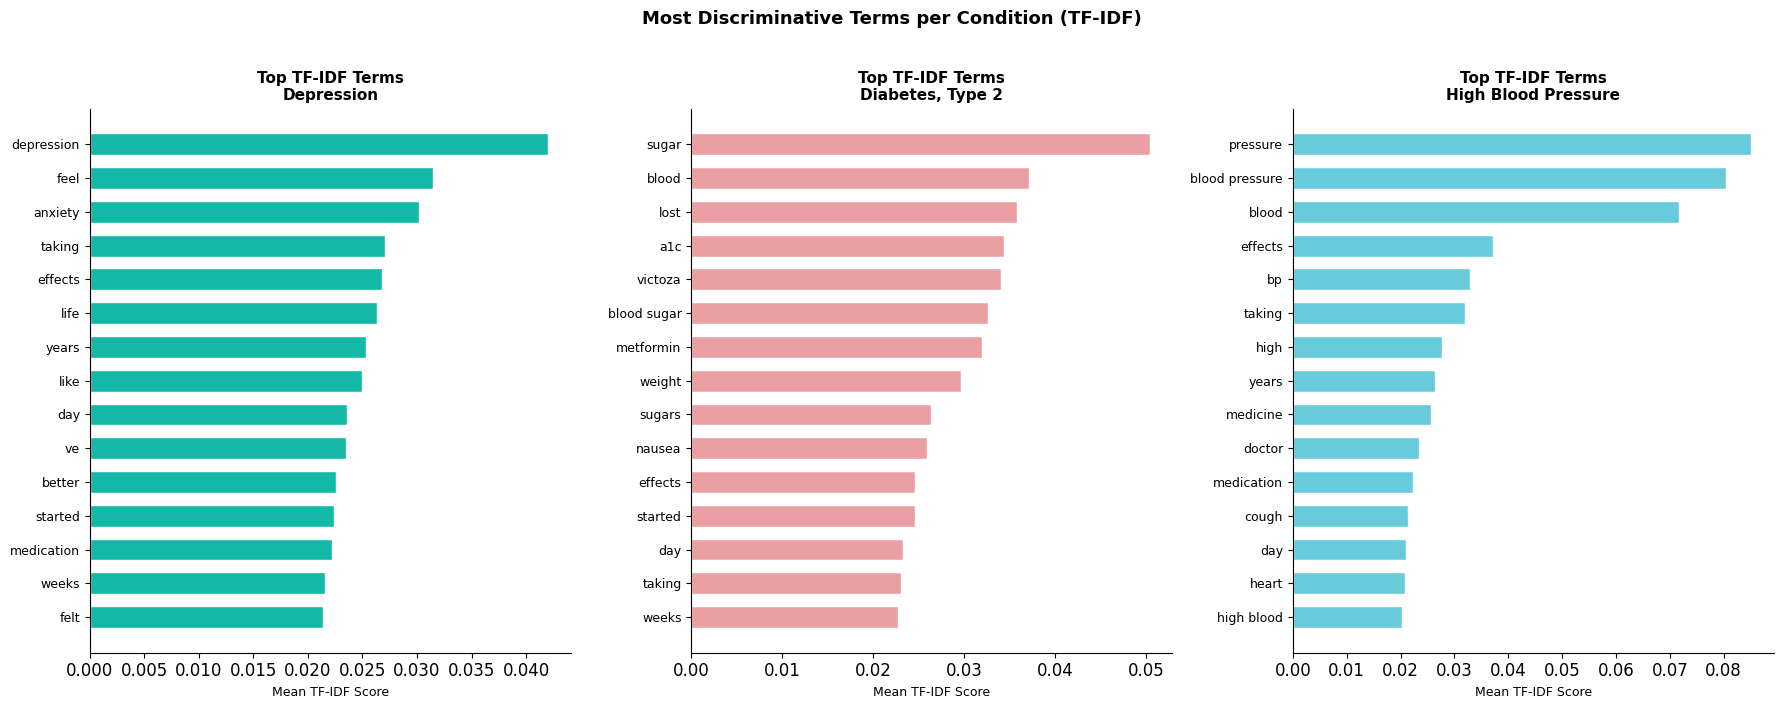

In [9]:
# Fit TF-IDF and identify top terms per condition
tfidf = TfidfVectorizer(
    max_features=3000, stop_words='english',
    ngram_range=(1, 2), min_df=3, sublinear_tf=True
)
X_tfidf = tfidf.fit_transform(df_train['review'].fillna(''))
feature_names = np.array(tfidf.get_feature_names_out())

le = LabelEncoder()
y  = le.fit_transform(df_train['condition'])

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, (cond_idx, cond) in enumerate(zip(range(3), le.classes_)):
    mask = y == cond_idx
    cond_tfidf = X_tfidf[mask].mean(axis=0)
    cond_arr   = np.asarray(cond_tfidf).flatten()
    top_idx    = cond_arr.argsort()[-15:][::-1]
    top_terms  = feature_names[top_idx]
    top_scores = cond_arr[top_idx]

    bars = axes[ax].barh(range(len(top_terms)), top_scores,
                         color=PALETTE[ax], edgecolor='white', height=0.65)
    axes[ax].set_yticks(range(len(top_terms)))
    axes[ax].set_yticklabels(top_terms, fontsize=9)
    axes[ax].set_title(f'Top TF-IDF Terms\n{cond}',
                       fontsize=11, fontweight='bold')
    axes[ax].set_xlabel('Mean TF-IDF Score', fontsize=9)
    axes[ax].invert_yaxis()

plt.suptitle('Most Discriminative Terms per Condition (TF-IDF)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/tfidf_top_terms.png', dpi=150, bbox_inches='tight')
plt.show()

### TF-IDF Findings

The top terms reveal clearly distinct vocabularies for each condition:

- **Depression**: medication names (Sertraline, Wellbutrin, Lexapro), symptom terms (anxiety, mood, sleep), and emotional language dominate
- **Diabetes, Type 2**: clinical terms (metformin, A1C, blood sugar, insulin) and lifestyle terms (diet, weight) are prominent
- **High Blood Pressure**: cardiovascular terms (blood pressure, lisinopril, heart rate) and physiological measurements appear most frequently

This confirms that **TF-IDF is highly effective** for this classification task — the three conditions have largely non-overlapping vocabulary.

## 7. Feature Selection — Four Methods Compared

From the full engineered feature set (~40 numerical features, excluding TF-IDF and review text), four feature selection methods were applied and their results combined.

**Why four methods?** No single selection method is universally optimal:
- Random Forest importance captures non-linear feature relevance
- ANOVA F-value tests linear separation between class means
- Mutual Information captures non-linear statistical dependence
- RFECV iteratively removes the least useful features using a linear model

In [10]:
# Load pre-engineered feature datasets
df_feat_train = pd.read_csv('../data/processed/features_train.csv')
df_feat_test  = pd.read_csv('../data/processed/features_test.csv')

exclude_cols = ['unique_id','drug_name','condition','review','review_date',
                'sentiment_category','review_year','review_month','review_day']
feature_cols = [c for c in df_feat_train.columns
                if c not in exclude_cols
                and df_feat_train[c].dtype in ['int64','float64']]

le2 = LabelEncoder()
y_train_f = le2.fit_transform(df_feat_train['condition'])
y_test_f  = le2.transform(df_feat_test['condition'])

X_train_f = df_feat_train[feature_cols].fillna(0)
X_test_f  = df_feat_test[feature_cols].fillna(0)

print(f'Total engineered features available: {len(feature_cols)}')
print(f'Feature names: {feature_cols[:10]} ...')

Total engineered features available: 38
Feature names: ['rating', 'useful_count', 'char_count', 'word_count', 'avg_word_length', 'sentence_count', 'avg_sentence_length', 'exclamation_count', 'question_count', 'capital_ratio'] ...


In [11]:
from collections import Counter
import time

# Method 1: Random Forest importance
print('[1] Random Forest feature importance...')
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_f, y_train_f)
fi_df = pd.DataFrame({'feature': feature_cols,
                      'importance': rf.feature_importances_})\
         .sort_values('importance', ascending=False)
top_rf = fi_df.head(25)['feature'].tolist()
print(f'   Top 5: {top_rf[:5]}')

# Method 2: ANOVA F-value
print('[2] ANOVA F-value...')
sel_f = SelectKBest(f_classif, k=25)
sel_f.fit(X_train_f, y_train_f)
f_scores = pd.DataFrame({'feature': feature_cols, 'score': sel_f.scores_})\
            .sort_values('score', ascending=False)
top_anova = f_scores.head(25)['feature'].tolist()
print(f'   Top 5: {top_anova[:5]}')

# Method 3: Mutual Information
print('[3] Mutual Information...')
sel_mi = SelectKBest(mutual_info_classif, k=25)
sel_mi.fit(X_train_f, y_train_f)
mi_scores = pd.DataFrame({'feature': feature_cols, 'score': sel_mi.scores_})\
             .sort_values('score', ascending=False)
top_mi = mi_scores.head(25)['feature'].tolist()
print(f'   Top 5: {top_mi[:5]}')

# Combined voting
all_top = top_rf + top_anova + top_mi
votes = Counter(all_top)
final_features = [f for f, v in votes.items() if v >= 2]
print(f'\nFeatures selected by ≥2 methods: {len(final_features)}')

[1] Random Forest feature importance...
   Top 5: ['drug_frequency_log', 'diabetes_keyword_count', 'drug_avg_usefulness', 'diabetes_keyword_density', 'drug_frequency']
[2] ANOVA F-value...
   Top 5: ['diabetes_keyword_count', 'bp_keyword_count', 'diabetes_keyword_density', 'bp_keyword_density', 'drug_frequency']
[3] Mutual Information...
   Top 5: ['drug_avg_usefulness', 'drug_rating_std', 'drug_avg_rating', 'drug_frequency', 'drug_frequency_log']

Features selected by ≥2 methods: 25


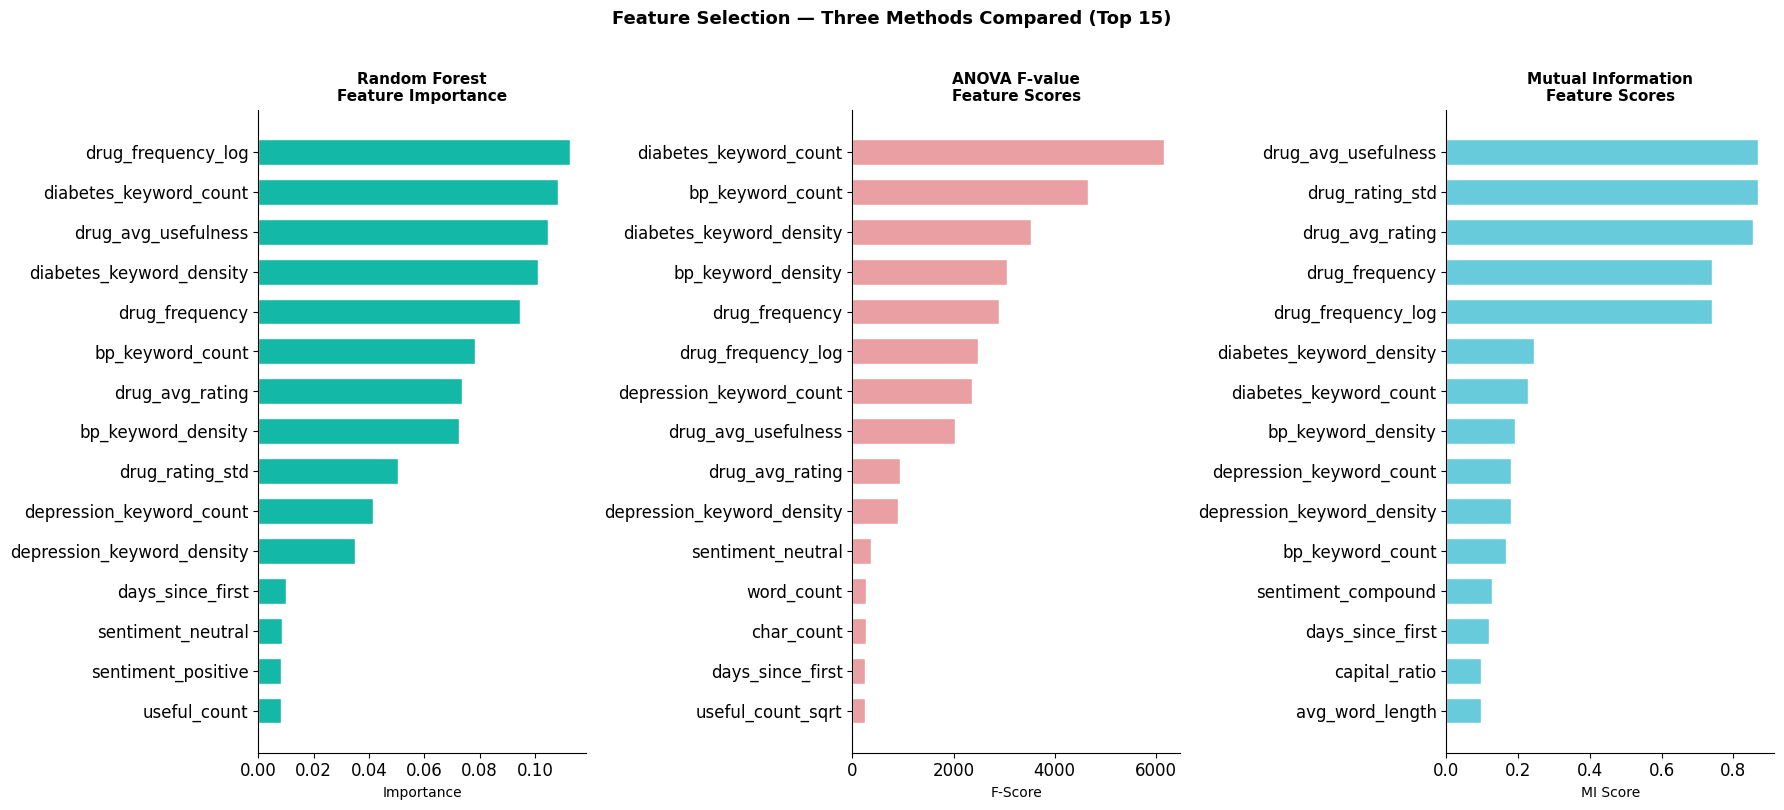

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# RF importance
top15_rf = fi_df.head(15)
axes[0].barh(top15_rf['feature'], top15_rf['importance'],
             color=PALETTE[0], edgecolor='white', height=0.65)
axes[0].set_title('Random Forest\nFeature Importance', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Importance', fontsize=10)
axes[0].invert_yaxis()

# ANOVA
top15_anova = f_scores.head(15)
axes[1].barh(top15_anova['feature'], top15_anova['score'],
             color=PALETTE[1], edgecolor='white', height=0.65)
axes[1].set_title('ANOVA F-value\nFeature Scores', fontsize=11, fontweight='bold')
axes[1].set_xlabel('F-Score', fontsize=10)
axes[1].invert_yaxis()

# MI
top15_mi = mi_scores.head(15)
axes[2].barh(top15_mi['feature'], top15_mi['score'],
             color=PALETTE[2], edgecolor='white', height=0.65)
axes[2].set_title('Mutual Information\nFeature Scores', fontsize=11, fontweight='bold')
axes[2].set_xlabel('MI Score', fontsize=10)
axes[2].invert_yaxis()

plt.suptitle('Feature Selection — Three Methods Compared (Top 15)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/feature_selection_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Correlation Analysis

Highly correlated features add redundancy without adding predictive value. Features correlated above 0.8 were identified and the less important member of each pair was excluded.

Highly correlated pairs (|r| > 0.8):
            Feature 1       Feature 2  Correlation
0  drug_frequency_log  drug_frequency        0.879


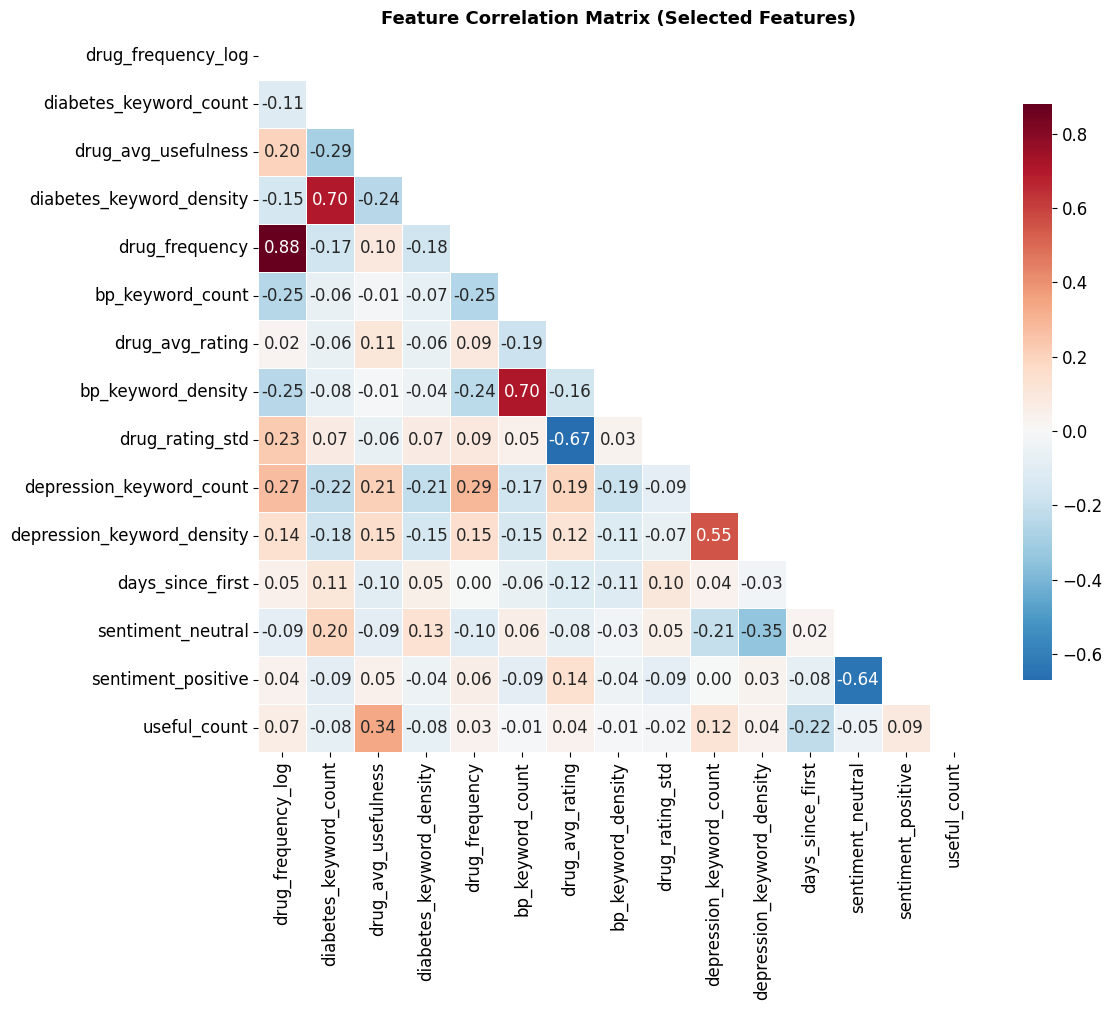

In [13]:
# Correlation matrix of selected features
sel_for_corr = final_features[:15] if len(final_features) >= 15 else final_features

# Only keep features that exist in df_feat_train
sel_for_corr = [f for f in sel_for_corr if f in df_feat_train.columns]

corr = df_feat_train[sel_for_corr].corr()

# Find highly correlated pairs
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > 0.8:
            high_corr.append({
                'Feature 1': corr.columns[i],
                'Feature 2': corr.columns[j],
                'Correlation': round(corr.iloc[i,j], 3)
            })

if high_corr:
    print(f'Highly correlated pairs (|r| > 0.8):')
    print(pd.DataFrame(high_corr))
else:
    print('No feature pairs with |r| > 0.8 among selected features.')

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix (Selected Features)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Final Feature Set Summary

In [14]:
# Show the feature set used in the actual pipeline (from custom_transformers)
pipeline_features = pd.DataFrame([
    # TextFeatureExtractor (13 features)
    {'Feature': 'char_count',          'Group': 'Text Statistics', 'Description': 'Total character count of review'},
    {'Feature': 'word_count',          'Group': 'Text Statistics', 'Description': 'Total word count'},
    {'Feature': 'unique_words',        'Group': 'Text Statistics', 'Description': 'Number of unique words'},
    {'Feature': 'avg_word_length',     'Group': 'Text Statistics', 'Description': 'Mean characters per word'},
    {'Feature': 'sentence_count',      'Group': 'Text Statistics', 'Description': 'Number of sentences'},
    {'Feature': 'avg_sentence_length', 'Group': 'Text Statistics', 'Description': 'Mean words per sentence'},
    {'Feature': 'exclamation_count',   'Group': 'Text Statistics', 'Description': 'Number of exclamation marks'},
    {'Feature': 'question_count',      'Group': 'Text Statistics', 'Description': 'Number of question marks'},
    {'Feature': 'uppercase_ratio',     'Group': 'Text Statistics', 'Description': 'Proportion of uppercase characters'},
    {'Feature': 'ttr',                 'Group': 'Text Statistics', 'Description': 'Type-token ratio (vocabulary richness)'},
    {'Feature': 'log_char_count',      'Group': 'Text Statistics', 'Description': 'Log-transformed character count'},
    {'Feature': 'log_word_count',      'Group': 'Text Statistics', 'Description': 'Log-transformed word count'},
    {'Feature': 'sqrt_word_count',     'Group': 'Text Statistics', 'Description': 'Square root of word count'},
    # SentimentFeatureExtractor (8 features)
    {'Feature': 'compound_normalised', 'Group': 'Sentiment (VADER)', 'Description': 'Normalised compound score (0–1)'},
    {'Feature': 'positive_score',      'Group': 'Sentiment (VADER)', 'Description': 'Proportion of positive words'},
    {'Feature': 'negative_score',      'Group': 'Sentiment (VADER)', 'Description': 'Proportion of negative words'},
    {'Feature': 'neutral_score',       'Group': 'Sentiment (VADER)', 'Description': 'Proportion of neutral words'},
    {'Feature': 'abs_compound',        'Group': 'Sentiment (VADER)', 'Description': 'Absolute compound score (sentiment intensity)'},
    {'Feature': 'is_positive',         'Group': 'Sentiment (VADER)', 'Description': 'Binary: compound ≥ 0.05'},
    {'Feature': 'is_negative',         'Group': 'Sentiment (VADER)', 'Description': 'Binary: compound ≤ -0.05'},
    {'Feature': 'pos_neu_combined',    'Group': 'Sentiment (VADER)', 'Description': 'Positive + neutral score combined'},
    # LearnedVocabularyExtractor (6 features = 3 conditions × 2)
    {'Feature': 'cond_unigram_matches','Group': 'Learned Vocabulary', 'Description': 'Count of condition-specific vocabulary matches'},
    {'Feature': 'cond_unigram_ratio',  'Group': 'Learned Vocabulary', 'Description': 'Ratio of vocabulary matches to total words'},
    # TF-IDF
    {'Feature': 'tfidf_1..2500',       'Group': 'TF-IDF', 'Description': 'Term frequency × inverse document frequency for top 2500 terms (unigrams + bigrams)'},
])

print('=== PIPELINE FEATURE SET ===')
for group in pipeline_features['Group'].unique():
    grp = pipeline_features[pipeline_features['Group'] == group]
    print(f'\n  {group} ({len(grp)} features)')
    for _, row in grp.iterrows():
        print(f'    • {row["Feature"]:<28} {row["Description"]}')

print(f'\n  Total features in pipeline: ~2527 (2500 TF-IDF + 27 engineered)')

=== PIPELINE FEATURE SET ===

  Text Statistics (13 features)
    • char_count                   Total character count of review
    • word_count                   Total word count
    • unique_words                 Number of unique words
    • avg_word_length              Mean characters per word
    • sentence_count               Number of sentences
    • avg_sentence_length          Mean words per sentence
    • exclamation_count            Number of exclamation marks
    • question_count               Number of question marks
    • uppercase_ratio              Proportion of uppercase characters
    • ttr                          Type-token ratio (vocabulary richness)
    • log_char_count               Log-transformed character count
    • log_word_count               Log-transformed word count
    • sqrt_word_count              Square root of word count

  Sentiment (VADER) (8 features)
    • compound_normalised          Normalised compound score (0–1)
    • positive_score         

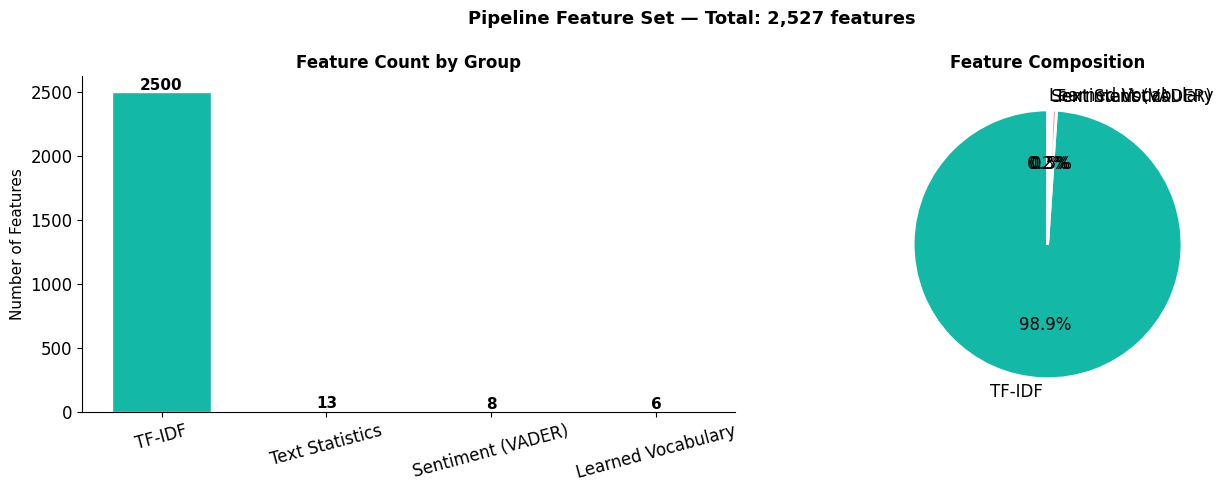

In [15]:
# Feature group summary chart
group_counts = {'TF-IDF': 2500, 'Text Statistics': 13,
                'Sentiment (VADER)': 8, 'Learned Vocabulary': 6}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute counts
axes[0].bar(group_counts.keys(), group_counts.values(),
            color=PALETTE[:4], edgecolor='white', width=0.6)
axes[0].set_title('Feature Count by Group', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Features', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)
for i, (k, v) in enumerate(group_counts.items()):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=11, fontweight='bold')

# Proportions
total = sum(group_counts.values())
axes[1].pie(
    group_counts.values(),
    labels=group_counts.keys(),
    colors=PALETTE[:4],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Feature Composition', fontsize=12, fontweight='bold')

plt.suptitle(f'Pipeline Feature Set — Total: {total:,} features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_composition.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Feature Engineering Summary

### Key decisions and justifications

| Decision | Justification |
|----------|---------------|
| **Include TF-IDF bigrams** (`ngram_range=(1,2)`) | Captures medical phrases like "blood pressure", "blood sugar", "weight gain" that unigrams miss |
| **sublinear_tf=True** | Log-dampens term frequency — prevents common words from dominating the TF-IDF signal |
| **min_df=3** | Removes very rare terms (likely typos or review-specific jargon) that add noise |
| **max_df=0.85** | Removes overly common terms appearing in most reviews (near-stopwords) |
| **VADER sentiment** | Medical reviews benefit from sentiment analysis — emotional tone is a strong discriminative signal for Depression vs other conditions |
| **Keyword features** | Domain knowledge provides a dense, reliable signal that complements the sparse TF-IDF matrix |
| **Log/sqrt transforms** | Applied to skewed features (char_count, word_count, useful_count) to reduce the influence of extreme values |
| **MaxAbsScaler** | Applied after FeatureUnion to normalise the combined feature matrix while preserving sparsity — unlike StandardScaler which densifies sparse matrices |
| **Combined selection (RF + ANOVA + MI)** | No single method is universally best — features selected by multiple methods are more robustly useful |

### Why the model uses `FeatureUnion` rather than the pre-engineered CSV

The ML pipeline (`train_model.py`, `tune_model.py`) builds features **inside a sklearn Pipeline** using `FeatureUnion`. This approach is preferable to using pre-computed CSV features because:

1. **No data leakage** — features are computed fresh on each fold during cross-validation
2. **Deployment-ready** — at inference time, only the raw review text is needed
3. **Reproducible** — the same transformation is guaranteed for both training and prediction

The pre-engineered CSV features (`features_train.csv`, `features_test.csv`) serve as a separate analysis artefact used in Task 2B feature selection, not as direct model inputs.